In [1]:
import pandas as pd

In [2]:
df = pd.read_excel("ecommerce_customer_churn_cleaned.xlsx")

df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43,Male,France,Marseille,2.9,14,27.4,6.0,50.6,3,...,17.9,9,4,16.3,20.8,1,953.33,2278,0,Q1
1,36,Male,UK,Manchester,1.6,15,42.7,10.3,37.7,1,...,42.8,7,3,27.6,23.3,3,1067.47,3028,0,Q4
2,45,Female,Canada,Vancouver,2.9,10,24.8,1.6,70.9,1,...,0.0,4,1,27.6,8.8,2,1289.75,2317,0,Q4
3,56,Female,USA,New York,2.6,10,38.4,14.8,41.7,9,...,41.4,2,5,85.9,31.0,3,2340.92,2674,0,Q1
4,35,Male,India,Delhi,3.1,29,51.4,8.4,19.1,9,...,37.9,1,11,83.0,50.4,4,3041.29,5354,0,Q4


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score
)

In [4]:
df = pd.read_excel("ecommerce_customer_churn_cleaned.xlsx")

df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43,Male,France,Marseille,2.9,14,27.4,6.0,50.6,3,...,17.9,9,4,16.3,20.8,1,953.33,2278,0,Q1
1,36,Male,UK,Manchester,1.6,15,42.7,10.3,37.7,1,...,42.8,7,3,27.6,23.3,3,1067.47,3028,0,Q4
2,45,Female,Canada,Vancouver,2.9,10,24.8,1.6,70.9,1,...,0.0,4,1,27.6,8.8,2,1289.75,2317,0,Q4
3,56,Female,USA,New York,2.6,10,38.4,14.8,41.7,9,...,41.4,2,5,85.9,31.0,3,2340.92,2674,0,Q1
4,35,Male,India,Delhi,3.1,29,51.4,8.4,19.1,9,...,37.9,1,11,83.0,50.4,4,3041.29,5354,0,Q4


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 50000
Columns: 25


In [6]:
print(df["Churned"].value_counts())

Churned
0    35550
1    14450
Name: count, dtype: int64


In [7]:
churn_percentage = df["Churned"].value_counts(normalize=True) * 100

print(churn_percentage)

Churned
0    71.1
1    28.9
Name: proportion, dtype: float64


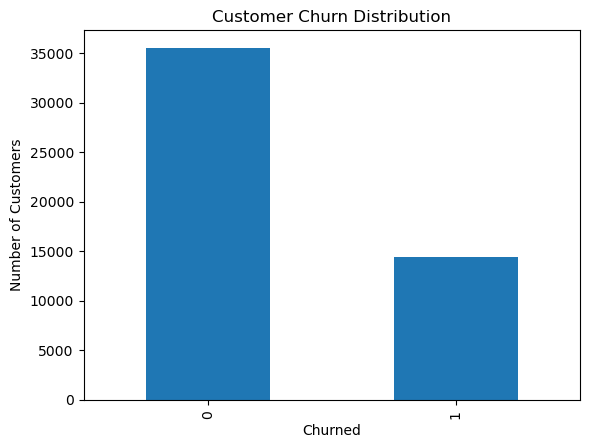

In [8]:
df["Churned"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churned")
plt.ylabel("Number of Customers")

plt.show()

In [9]:
X = df.drop("Churned", axis=1)

y = df["Churned"]

In [10]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000, 24)
y shape: (50000,)


In [11]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Age', 'Membership_Years', 'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session', 'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases', 'Average_Order_Value', 'Days_Since_Last_Purchase', 'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate', 'Customer_Service_Calls', 'Product_Reviews_Written', 'Social_Media_Engagement_Score', 'Mobile_App_Usage', 'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance']

Categorical Features:
['Gender', 'Country', 'City', 'Signup_Quarter']


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [13]:
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (40000, 24)
Testing set: (10000, 24)


In [14]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [15]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [17]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

In [18]:
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Membership_Years',
                                                   'Login_Frequency',
                                                   'Session_Duration_Avg',
                                                   'Pages_Per_Session',
                                                   'Cart_Abandonment_Rate',
                                                   'Wishlist_Items',
                                                   'Total_Purchases',
                                                   'Average_Order_Value',
                                                   'Days_Since_Last_Pur...
                                                   'Social_Media_Engagement_Score',
                                                   'Mobile_App_Usage',
                                                   'Payment_Method_Diversity',
                                                   'Lifetime_Value',
                                                   'Credit_Balance']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Country', 'City',
                                                   'Signup_Quarter'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [19]:
print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [20]:
y_pred_logistic = logistic_model.predict(X_test)

In [21]:
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic)
recall_logistic = recall_score(y_test, y_pred_logistic)
f1_logistic = f1_score(y_test, y_pred_logistic)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", accuracy_logistic)
print("Precision:", precision_logistic)
print("Recall   :", recall_logistic)
print("F1 Score :", f1_logistic)

Logistic Regression Results
---------------------------
Accuracy : 0.7758
Precision: 0.6792035398230089
Recall   : 0.4249134948096886
F1 Score : 0.5227756492124308


In [22]:
print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

           0       0.80      0.92      0.85      7110
           1       0.68      0.42      0.52      2890

    accuracy                           0.78     10000
   macro avg       0.74      0.67      0.69     10000
weighted avg       0.76      0.78      0.76     10000



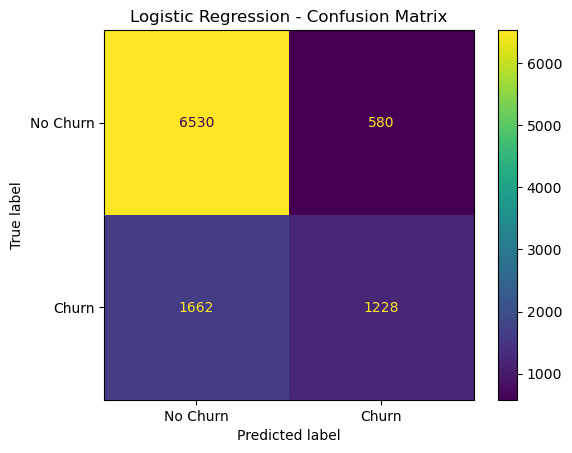

In [23]:
cm = confusion_matrix(y_test, y_pred_logistic)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [24]:
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

roc_auc_logistic = roc_auc_score(y_test, y_prob_logistic)

print("ROC-AUC:", roc_auc_logistic)

ROC-AUC: 0.7909229653638572


In [25]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [26]:
random_forest_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [27]:
y_pred_rf = random_forest_model.predict(X_test)

In [28]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)

Random Forest Results
---------------------
Accuracy : 0.9144
Precision: 0.9226932668329177
Recall   : 0.7681660899653979
F1 Score : 0.8383685800604229


In [29]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7110
           1       0.92      0.77      0.84      2890

    accuracy                           0.91     10000
   macro avg       0.92      0.87      0.89     10000
weighted avg       0.91      0.91      0.91     10000



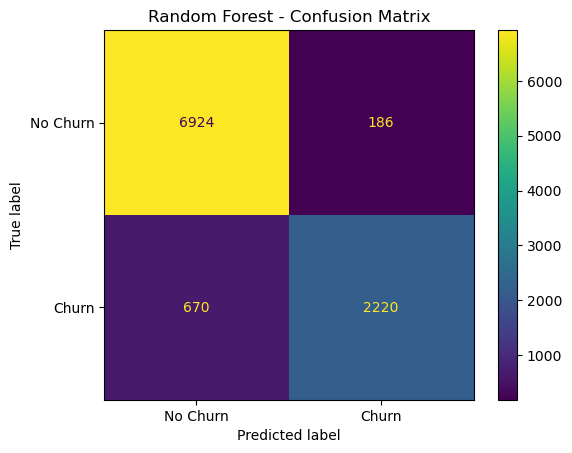

In [30]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No Churn", "Churn"]
)

disp_rf.plot()

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [31]:
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("ROC-AUC:", roc_auc_rf)

ROC-AUC: 0.9242489256809698


In [32]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_rf
    ],
    "Precision": [
        precision_logistic,
        precision_rf
    ],
    "Recall": [
        recall_logistic,
        recall_rf
    ],
    "F1 Score": [
        f1_logistic,
        f1_rf
    ],
    "ROC-AUC": [
        roc_auc_logistic,
        roc_auc_rf
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7758,0.679204,0.424913,0.522776,0.790923
1,Random Forest,0.9144,0.922693,0.768166,0.838369,0.924249


In [33]:
results.sort_values("F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Random Forest,0.9144,0.922693,0.768166,0.838369,0.924249
0,Logistic Regression,0.7758,0.679204,0.424913,0.522776,0.790923


In [34]:
import joblib

joblib.dump(
    random_forest_model,
    "customer_churn_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!
